In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Load the corrected WQI dataset
file_path = "C:\PCCOE\Final Year Project - A02\Final Submission\ML Model\WQI_data.csv"
df = pd.read_csv(file_path)

# Separate features (pH, TDS, Turbidity) and target (WQI)
X = df[['pH', 'TDS', 'Turbidity']]
y = df['WQI']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Save the trained model
model_path = "C:\PCCOE\Final Year Project - A02\Predictive Model\wqi_rf_model.pkl"
joblib.dump(rf_model, model_path)

# Return model performance
mae, r2, model_path


(0.6656800000000025,
 0.98483561653957,
 'C:\\PCCOE\\Final Year Project - A02\\Predictive Model\\wqi_rf_model.pkl')

In [6]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(mae_lr , r2_lr)

0.16735653302420717 0.999127019992742


In [10]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print(mae_svr , r2_svr)

4.046636035354293 0.49958057344433326


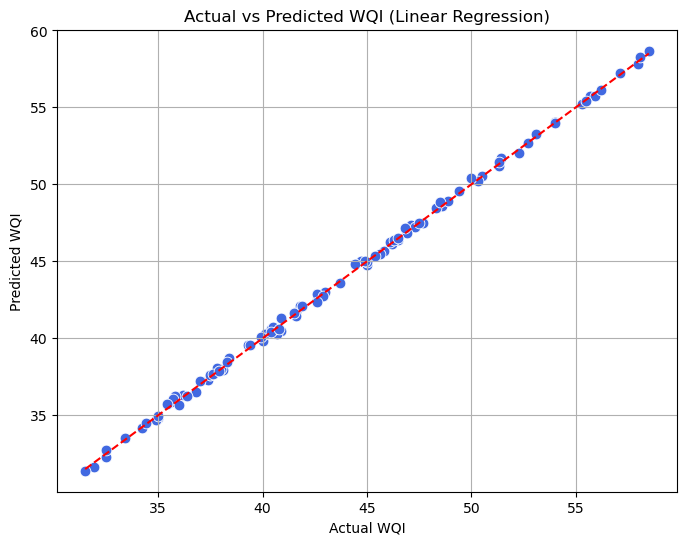

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, color='royalblue', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title("Actual vs Predicted WQI (Linear Regression)")
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred_lr)
rmse = mean_squared_error(y_test, y_pred_lr, squared=False)

print(f"MAE: {mae_lr:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2 Score: {r2_lr:.3f}")

MAE: 0.167
MSE: 0.041
RMSE: 0.202
R2 Score: 0.999


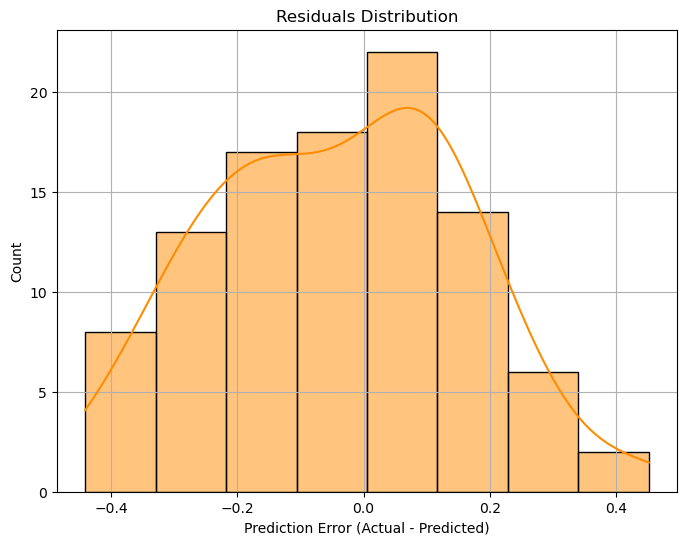

In [16]:
residuals = y_test - y_pred_lr
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='darkorange')
plt.title("Residuals Distribution")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.grid(True)
plt.show()
